In [22]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

print("PyTorch version:", torch.__version__)
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

PyTorch version: 2.14.0+cpu
Device: cpu


In [4]:
# Project paths
project_root = Path.cwd().parent

if not (project_root / "data").exists():
    project_root = Path.cwd().parent.parent

print("Project root:", project_root)

# Load cleaned metadata
processed_dir = project_root / "data" / "processed"

clean_metadata_path = (
    processed_dir / "agrisense_metadata_clean.csv"
)

df_clean = pd.read_csv(clean_metadata_path)

print("Shape:", df_clean.shape)
print("Columns:", df_clean.columns.tolist())

print("\nSplit counts:")
print(df_clean["Split"].value_counts())

print("\nMissing values:", df_clean.isna().sum().sum())

Project root: c:\Users\Dell\Documents\Projects\AgriSense
Shape: (7399, 11)
Columns: ['Name', 'Index', 'Plant', 'Disease', 'Resolution', 'Label file', 'Mask ratio', 'URL', 'License', 'Split', 'image_hash']

Split counts:
Split
Training      5084
Test          1504
Validation     811
Name: count, dtype: int64

Missing values: 0


In [5]:
# Locating the image and mask files

# Dataset directories
image_root = project_root / "data" / "raw" / "PlantSeg" / "images"
annotation_root = project_root / "data" / "raw" / "PlantSeg" / "annotations"

print("Image directory exists:", image_root.exists())
print("Annotation directory exists:", annotation_root.exists())

print("\nAnnotation folders:")
if annotation_root.exists():
    for path in annotation_root.iterdir():
        print(path)

Image directory exists: True
Annotation directory exists: True

Annotation folders:
c:\Users\Dell\Documents\Projects\AgriSense\data\raw\PlantSeg\annotations\test
c:\Users\Dell\Documents\Projects\AgriSense\data\raw\PlantSeg\annotations\train
c:\Users\Dell\Documents\Projects\AgriSense\data\raw\PlantSeg\annotations\val


In [6]:
# Building actual image paths

# Building a lookup for all image files
image_files = list(image_root.rglob("*"))

image_lookup = {
    path.name: path
    for path in image_files
    if path.is_file()
}

print("Image files found:", len(image_lookup))

# Mapping each metadata record to its actual image path
df_clean["actual_image_path"] = df_clean["Name"].map(image_lookup)

print(
    "Missing image paths:",
    df_clean["actual_image_path"].isna().sum()
)

Image files found: 7774
Missing image paths: 0


In [7]:
# Building actual mask paths

# Building a lookup for all mask files
mask_files = list(annotation_root.rglob("*.png"))

mask_lookup = {
    path.name: path
    for path in mask_files
}

print("Mask files found:", len(mask_lookup))

# Mapping each metadata record to its actual mask path
df_clean["actual_mask_path"] = df_clean["Label file"].map(mask_lookup)

print(
    "Missing mask paths:",
    df_clean["actual_mask_path"].isna().sum()
)

Mask files found: 7774
Missing mask paths: 0


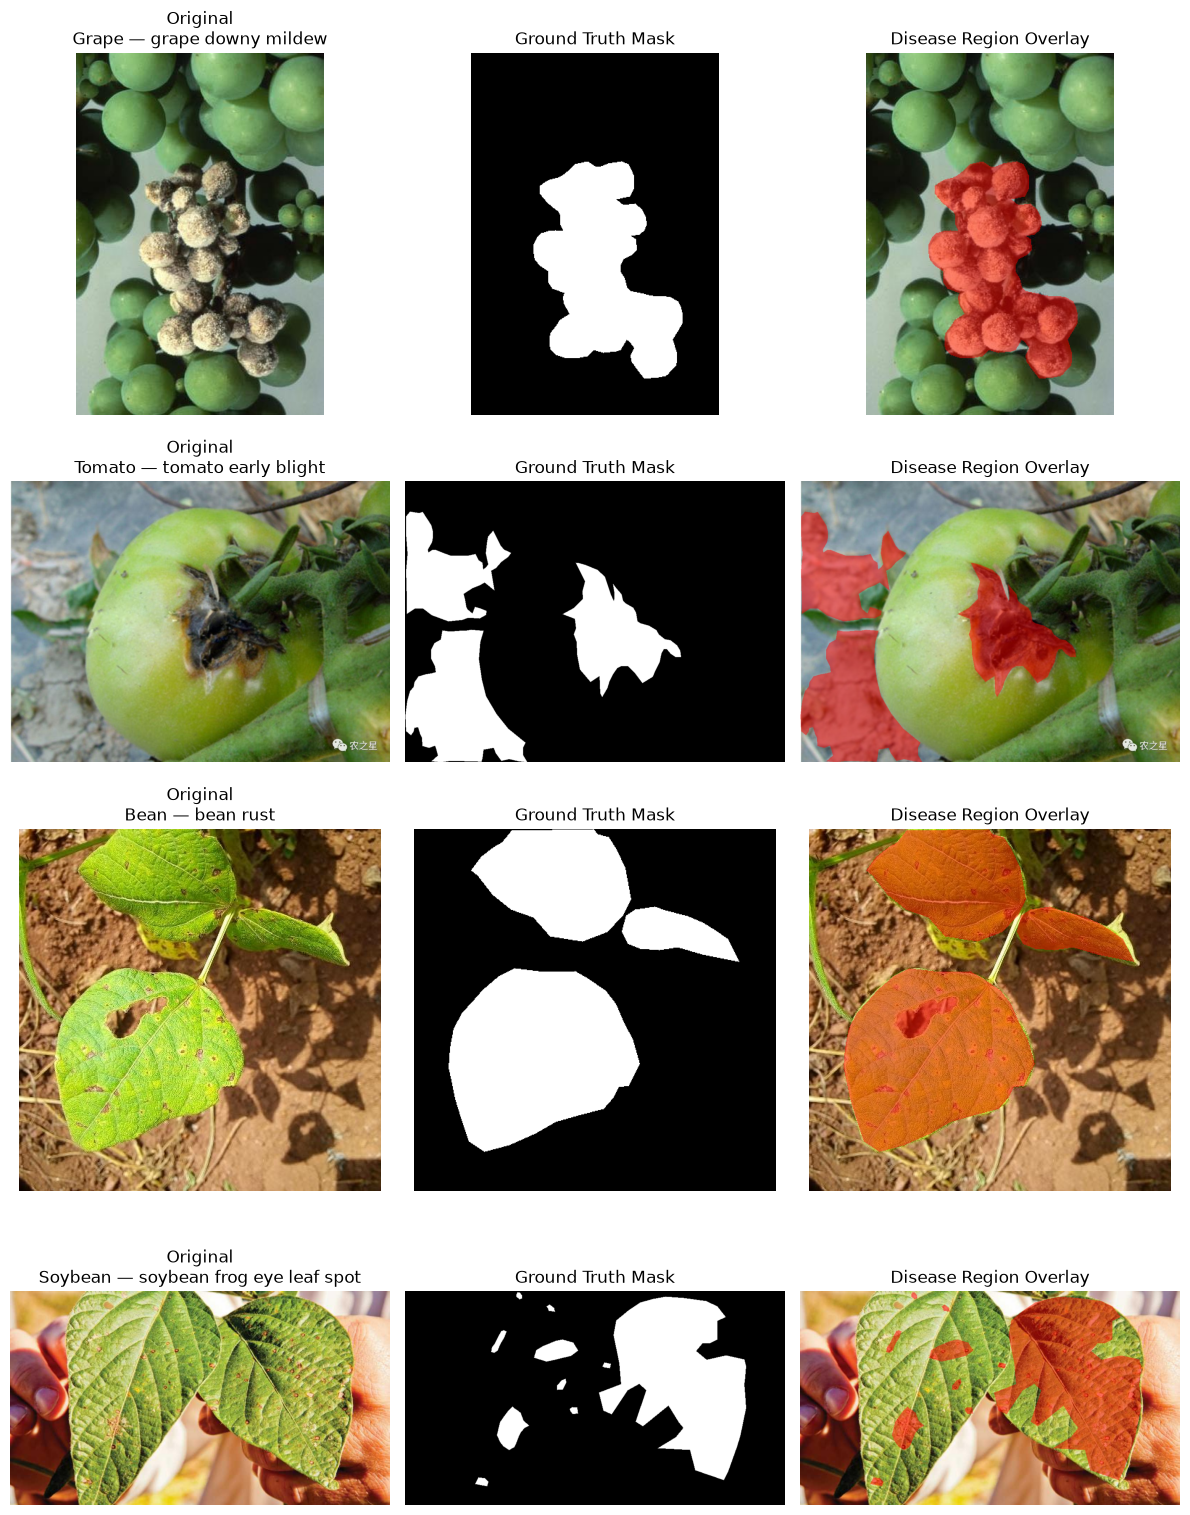

In [8]:
# Inspecting image + disease mask

def show_mask_samples(df, n=4):
    samples = df.sample(n=n, random_state=42)

    fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))

    for row_idx, (_, row) in enumerate(samples.iterrows()):
        image = Image.open(row["actual_image_path"]).convert("RGB")
        mask = Image.open(row["actual_mask_path"]).convert("L")

        image_np = np.array(image)
        mask_np = np.array(mask)

        # Binary disease mask
        binary_mask = mask_np > 0

        # Overlay
        overlay = image_np.copy()
        overlay[binary_mask] = (
            0.5 * overlay[binary_mask] +
            0.5 * np.array([255, 0, 0])
        ).astype(np.uint8)

        axes[row_idx, 0].imshow(image_np)
        axes[row_idx, 0].set_title(
            f"Original\n{row['Plant']} — {row['Disease']}"
        )

        axes[row_idx, 1].imshow(binary_mask, cmap="gray")
        axes[row_idx, 1].set_title("Ground Truth Mask")

        axes[row_idx, 2].imshow(overlay)
        axes[row_idx, 2].set_title("Disease Region Overlay")

        for col in range(3):
            axes[row_idx, col].axis("off")

    plt.tight_layout()
    plt.show()


show_mask_samples(df_clean)

In [9]:
# Image / mask preprocessing

IMAGE_SIZE = (224, 224)

def load_segmentation_sample(image_path, mask_path):
    # Load image
    image = Image.open(image_path).convert("RGB")

    # Load mask
    mask = Image.open(mask_path).convert("L")

    # Resize both to the same spatial dimensions
    image = image.resize(IMAGE_SIZE, Image.Resampling.BILINEAR)
    mask = mask.resize(IMAGE_SIZE, Image.Resampling.NEAREST)

    # Convert to arrays
    image = np.array(image)
    mask = np.array(mask)

    # Binary disease mask
    mask = (mask > 0).astype(np.float32)

    return image, mask


# Test one sample
sample_image, sample_mask = load_segmentation_sample(
    df_clean.iloc[0]["actual_image_path"],
    df_clean.iloc[0]["actual_mask_path"]
)

print("Image shape:", sample_image.shape)
print("Mask shape:", sample_mask.shape)
print("Mask unique values:", np.unique(sample_mask))

Image shape: (224, 224, 3)
Mask shape: (224, 224)
Mask unique values: [0. 1.]


In [11]:
# Segmentation dataset and dataloaders

class PlantSegmentationDataset(Dataset):

    def __init__(self, dataframe):
        self.dataframe = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        image, mask = load_segmentation_sample(
            row["actual_image_path"],
            row["actual_mask_path"]
        )

        # Image: HWC -> CHW and normalize to [0, 1]
        image = torch.tensor(
            image, dtype=torch.float32
        ).permute(2, 0, 1) / 255.0

        # Mask: H,W -> 1,H,W
        mask = torch.tensor(
            mask, dtype=torch.float32
        ).unsqueeze(0)

        return image, mask

In [12]:
# Train Validation and Test datasets

train_df = df_clean[df_clean["Split"] == "Training"].copy()
val_df = df_clean[df_clean["Split"] == "Validation"].copy()
test_df = df_clean[df_clean["Split"] == "Test"].copy()

train_dataset = PlantSegmentationDataset(train_df)
val_dataset = PlantSegmentationDataset(val_df)
test_dataset = PlantSegmentationDataset(test_df)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

Train samples: 5084
Validation samples: 811
Test samples: 1504


In [13]:
# Data Loaders

BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 318
Validation batches: 51
Test batches: 94


In [14]:
#Verifying a real Batch

images, masks = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Mask batch shape:", masks.shape)
print("Image range:", images.min().item(), "to", images.max().item())
print("Mask values:", torch.unique(masks))

Image batch shape: torch.Size([16, 3, 224, 224])
Mask batch shape: torch.Size([16, 1, 224, 224])
Image range: 0.0 to 1.0
Mask values: tensor([0., 1.])


In [15]:
# UNet Seg Model

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.enc1 = DoubleConv(3, 32)
        self.enc2 = DoubleConv(32, 64)
        self.enc3 = DoubleConv(64, 128)

        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConv(128, 256)

        # Decoder
        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(64, 32)

        # Output: one channel = disease probability/logit
        self.output = nn.Conv2d(32, 1, kernel_size=1)

    def forward(self, x):

        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        # Bottleneck
        b = self.bottleneck(self.pool(e3))

        # Decoder
        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.output(d1)

In [16]:
# Initialize and test the model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet().to(device)

print("Device:", device)

total_params = sum(
    p.numel() for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

# Forward-pass test
sample_images, sample_masks = next(iter(train_loader))

sample_images = sample_images.to(device)

with torch.no_grad():
    sample_output = model(sample_images)

print("Input shape:", sample_images.shape)
print("Output shape:", sample_output.shape)

Device: cpu
Total parameters: 1928417
Trainable parameters: 1928417
Input shape: torch.Size([16, 3, 224, 224])
Output shape: torch.Size([16, 1, 224, 224])


In [17]:
# Dice loss + Combined loss

def dice_loss(logits, targets, smooth=1.0):
    probabilities = torch.sigmoid(logits)

    probabilities = probabilities.view(probabilities.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    intersection = (probabilities * targets).sum(dim=1)

    dice = (
        (2.0 * intersection + smooth)
        / (
            probabilities.sum(dim=1)
            + targets.sum(dim=1)
            + smooth
        )
    )

    return 1.0 - dice.mean()


bce_loss = nn.BCEWithLogitsLoss()


def combined_loss(logits, targets):
    bce = bce_loss(logits, targets)
    dice = dice_loss(logits, targets)

    return bce + dice

In [18]:
# Optimizer

criterion = combined_loss

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Optimizer:", optimizer)
print("Learning rate:", 0.001)

Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
Learning rate: 0.001


In [19]:
# Loss sanity check

images, masks = next(iter(train_loader))

images = images.to(device)
masks = masks.to(device)

model.train()

optimizer.zero_grad()

outputs = model(images)

loss = criterion(outputs, masks)

print("Output shape:", outputs.shape)
print("Mask shape:", masks.shape)
print("Initial loss:", loss.item())

Output shape: torch.Size([16, 1, 224, 224])
Mask shape: torch.Size([16, 1, 224, 224])
Initial loss: 1.356691598892212


In [23]:
# Segmentation Training Loop

import time
from tqdm.auto import tqdm

NUM_EPOCHS = 5

history = []

best_val_loss = float("inf")

checkpoint_dir = project_root / "models" / "checkpoints"
checkpoint_dir.mkdir(parents=True, exist_ok=True)

latest_checkpoint_path = (
    checkpoint_dir / "unet_segmentation_latest.pth"
)

best_checkpoint_path = (
    checkpoint_dir / "unet_segmentation_best.pth"
)


for epoch in range(NUM_EPOCHS):

    start_time = time.time()

    # Training

    model.train()

    train_loss = 0.0

    train_progress = tqdm(
        train_loader,
        desc=f"Epoch {epoch + 1}/{NUM_EPOCHS} - Training"
    )

    for images, masks in train_progress:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, masks)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        train_progress.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    train_loss /= len(train_loader)

    # Validation

    model.eval()

    val_loss = 0.0

    val_progress = tqdm(
        val_loader,
        desc=f"Epoch {epoch + 1}/{NUM_EPOCHS} - Validation"
    )

    with torch.no_grad():

        for images, masks in val_progress:

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            loss = criterion(outputs, masks)

            val_loss += loss.item()

            val_progress.set_postfix(
                loss=f"{loss.item():.4f}"
            )

    val_loss /= len(val_loader)

    epoch_time = time.time() - start_time

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "time_seconds": epoch_time
    })

    print(
        f"Epoch {epoch + 1}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Time: {epoch_time/60:.1f} min"
    )

    # Save latest checkpoint
    torch.save({
        "epoch": epoch + 1,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "train_loss": train_loss,
        "val_loss": val_loss
    }, latest_checkpoint_path)

    # Save best checkpoint
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_loss": train_loss,
            "val_loss": val_loss
        }, best_checkpoint_path)

        print("  → Best checkpoint updated.")

Epoch 1/5 - Validation: 100%|██████████| 51/51 [03:02<00:00,  3.57s/it, loss=1.1472]


Epoch 1/5 | Train Loss: 1.1646 | Val Loss: 1.1410 | Time: 54.8 min
  → Best checkpoint updated.


Epoch 2/5 - Validation: 100%|██████████| 51/51 [03:11<00:00,  3.76s/it, loss=0.9636]


Epoch 2/5 | Train Loss: 1.0615 | Val Loss: 1.0230 | Time: 54.3 min
  → Best checkpoint updated.


Epoch 3/5 - Validation: 100%|██████████| 51/51 [03:09<00:00,  3.72s/it, loss=0.9091]


Epoch 3/5 | Train Loss: 1.0286 | Val Loss: 0.9912 | Time: 56.5 min
  → Best checkpoint updated.


Epoch 4/5 - Validation: 100%|██████████| 51/51 [02:47<00:00,  3.28s/it, loss=0.8275]


Epoch 4/5 | Train Loss: 0.9969 | Val Loss: 0.9663 | Time: 67.4 min
  → Best checkpoint updated.


Epoch 5/5 - Validation: 100%|██████████| 51/51 [02:50<00:00,  3.35s/it, loss=0.8537]

Epoch 5/5 | Train Loss: 0.9748 | Val Loss: 0.9463 | Time: 52.3 min
  → Best checkpoint updated.


In [24]:
# Load best segmentation checkpoint

checkpoint = torch.load(
    best_checkpoint_path,
    map_location=device
)

model.load_state_dict(checkpoint["model_state_dict"])

print("Best checkpoint loaded.")
print("Epoch:", checkpoint["epoch"])
print("Validation loss:", checkpoint["val_loss"])

Best checkpoint loaded.
Epoch: 5
Validation loss: 0.9462818199513006


In [25]:
# Segmentation Metrics

def calculate_segmentation_metrics(logits, targets, threshold=0.5, smooth=1e-7):
    probabilities = torch.sigmoid(logits)
    predictions = (probabilities >= threshold).float()

    predictions = predictions.view(predictions.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    intersection = (predictions * targets).sum(dim=1)

    prediction_area = predictions.sum(dim=1)
    target_area = targets.sum(dim=1)

    dice = (
        (2 * intersection + smooth)
        / (prediction_area + target_area + smooth)
    )

    union = prediction_area + target_area - intersection

    iou = (
        (intersection + smooth)
        / (union + smooth)
    )

    accuracy = (
        (predictions == targets)
        .float()
        .mean(dim=1)
    )

    return dice, iou, accuracy

In [26]:
# Evaluating on test set

model.eval()

test_dice = []
test_iou = []
test_accuracy = []

with torch.no_grad():

    test_progress = tqdm(
        test_loader,
        desc="Testing Segmentation Model"
    )

    for images, masks in test_progress:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        dice, iou, accuracy = calculate_segmentation_metrics(
            outputs,
            masks
        )

        test_dice.extend(dice.cpu().numpy())
        test_iou.extend(iou.cpu().numpy())
        test_accuracy.extend(accuracy.cpu().numpy())

test_dice = np.array(test_dice)
test_iou = np.array(test_iou)
test_accuracy = np.array(test_accuracy)

print("Test samples:", len(test_dice))
print(f"Mean Dice: {test_dice.mean():.4f}")
print(f"Mean IoU: {test_iou.mean():.4f}")
print(f"Mean Pixel Accuracy: {test_accuracy.mean():.4f}")

Testing Segmentation Model: 100%|██████████| 94/94 [04:32<00:00,  2.90s/it]

Test samples: 1504
Mean Dice: 0.5110
Mean IoU: 0.3857
Mean Pixel Accuracy: 0.8307


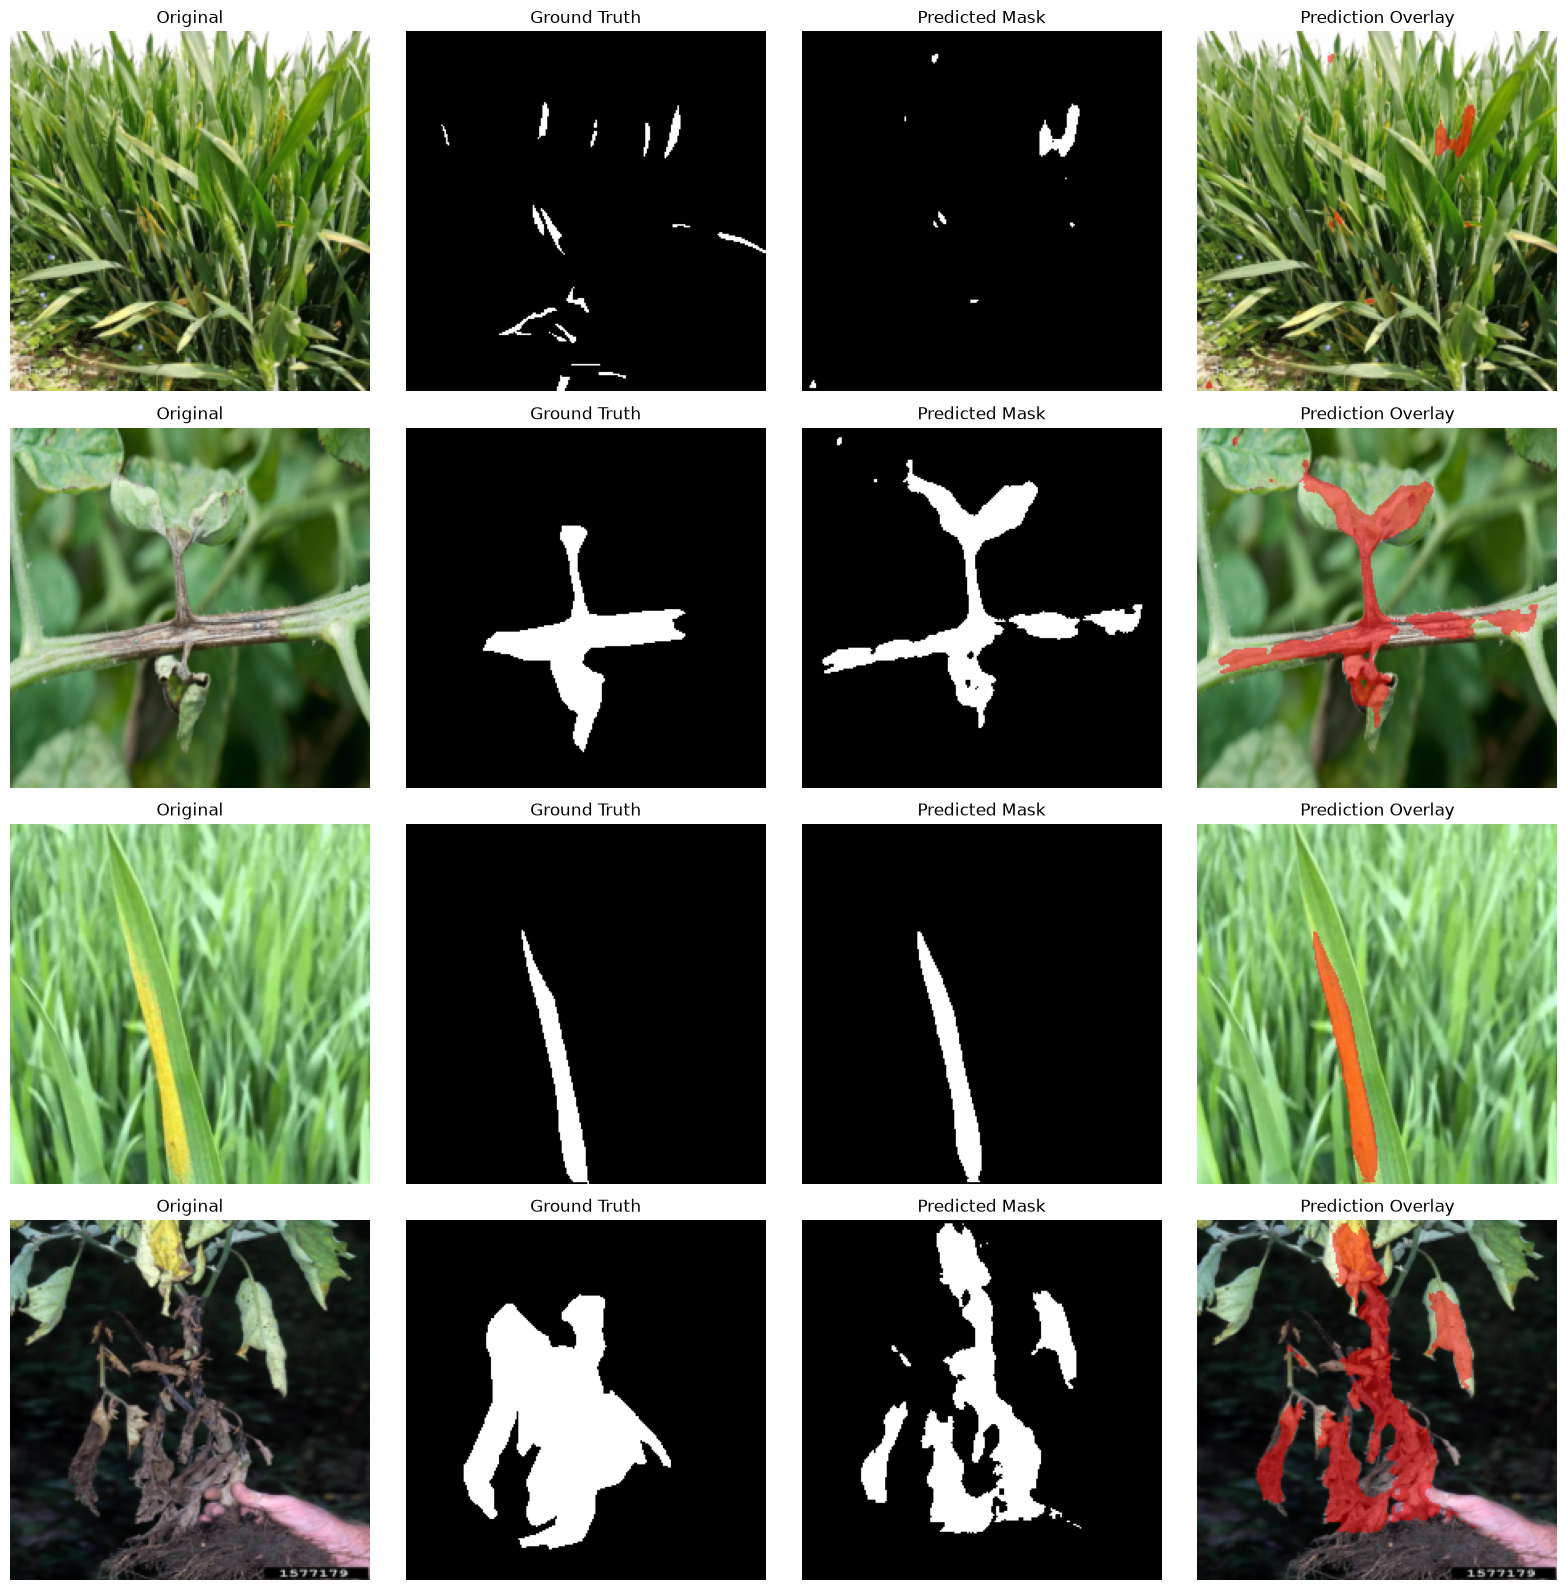

In [27]:
def show_segmentation_predictions(
    model,
    dataset,
    n=4,
    random_state=42
):
    model.eval()

    rng = np.random.default_rng(random_state)
    indices = rng.choice(len(dataset), size=n, replace=False)

    fig, axes = plt.subplots(n, 4, figsize=(16, 4 * n))

    with torch.no_grad():

        for row_idx, idx in enumerate(indices):

            image, mask = dataset[idx]

            input_tensor = image.unsqueeze(0).to(device)

            output = model(input_tensor)

            probability = torch.sigmoid(output)[0, 0].cpu().numpy()

            predicted_mask = probability >= 0.5

            image_np = image.permute(1, 2, 0).numpy()
            mask_np = mask.squeeze(0).numpy()

            # Prediction overlay
            overlay = (
                image_np * 255
            ).astype(np.uint8).copy()

            overlay[predicted_mask] = (
                0.5 * overlay[predicted_mask]
                + 0.5 * np.array([255, 0, 0])
            ).astype(np.uint8)

            axes[row_idx, 0].imshow(image_np)
            axes[row_idx, 0].set_title("Original")

            axes[row_idx, 1].imshow(
                mask_np,
                cmap="gray"
            )
            axes[row_idx, 1].set_title("Ground Truth")

            axes[row_idx, 2].imshow(
                predicted_mask,
                cmap="gray"
            )
            axes[row_idx, 2].set_title("Predicted Mask")

            axes[row_idx, 3].imshow(overlay)
            axes[row_idx, 3].set_title("Prediction Overlay")

            for col in range(4):
                axes[row_idx, col].axis("off")

    plt.tight_layout()
    plt.show()


show_segmentation_predictions(
    model,
    test_dataset,
    n=4
)

In [28]:
# finding best segmenttaion threshold

def evaluate_thresholds(model, loader, thresholds):
    model.eval()

    results = []

    with torch.no_grad():

        for threshold in thresholds:

            dice_scores = []
            iou_scores = []

            for images, masks in loader:

                images = images.to(device)
                masks = masks.to(device)

                outputs = model(images)

                dice, iou, _ = calculate_segmentation_metrics(
                    outputs,
                    masks,
                    threshold=threshold
                )

                dice_scores.extend(dice.cpu().numpy())
                iou_scores.extend(iou.cpu().numpy())

            results.append({
                "threshold": threshold,
                "dice": np.mean(dice_scores),
                "iou": np.mean(iou_scores)
            })

    return pd.DataFrame(results)


thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

threshold_results = evaluate_thresholds(
    model,
    val_loader,
    thresholds
)

print(threshold_results)

   threshold      dice       iou
0        0.2  0.506287  0.381384
1        0.3  0.517079  0.389367
2        0.4  0.517473  0.388348
3        0.5  0.507947  0.378778
4        0.6  0.485026  0.357665
5        0.7  0.433992  0.313407
6        0.8  0.341994  0.238453


In [29]:
best_threshold = threshold_results.loc[
    threshold_results["dice"].idxmax(),
    "threshold"
]

print("Best threshold:", best_threshold)

Best threshold: 0.4


In [30]:
# Final test evaluation using the threshold selected on validation data

model.eval()

test_dice_final = []
test_iou_final = []
test_accuracy_final = []

with torch.no_grad():

    test_progress = tqdm(
        test_loader,
        desc="Final Segmentation Test"
    )

    for images, masks in test_progress:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        dice, iou, accuracy = calculate_segmentation_metrics(
            outputs,
            masks,
            threshold=best_threshold
        )

        test_dice_final.extend(dice.cpu().numpy())
        test_iou_final.extend(iou.cpu().numpy())
        test_accuracy_final.extend(accuracy.cpu().numpy())

test_dice_final = np.array(test_dice_final)
test_iou_final = np.array(test_iou_final)
test_accuracy_final = np.array(test_accuracy_final)

print("Test samples:", len(test_dice_final))
print(f"Threshold used: {best_threshold}")
print(f"Mean Dice: {test_dice_final.mean():.4f}")
print(f"Mean IoU: {test_iou_final.mean():.4f}")
print(f"Mean Pixel Accuracy: {test_accuracy_final.mean():.4f}")

Final Segmentation Test: 100%|██████████| 94/94 [04:44<00:00,  3.02s/it]

Test samples: 1504
Threshold used: 0.4
Mean Dice: 0.5233
Mean IoU: 0.3971
Mean Pixel Accuracy: 0.8198


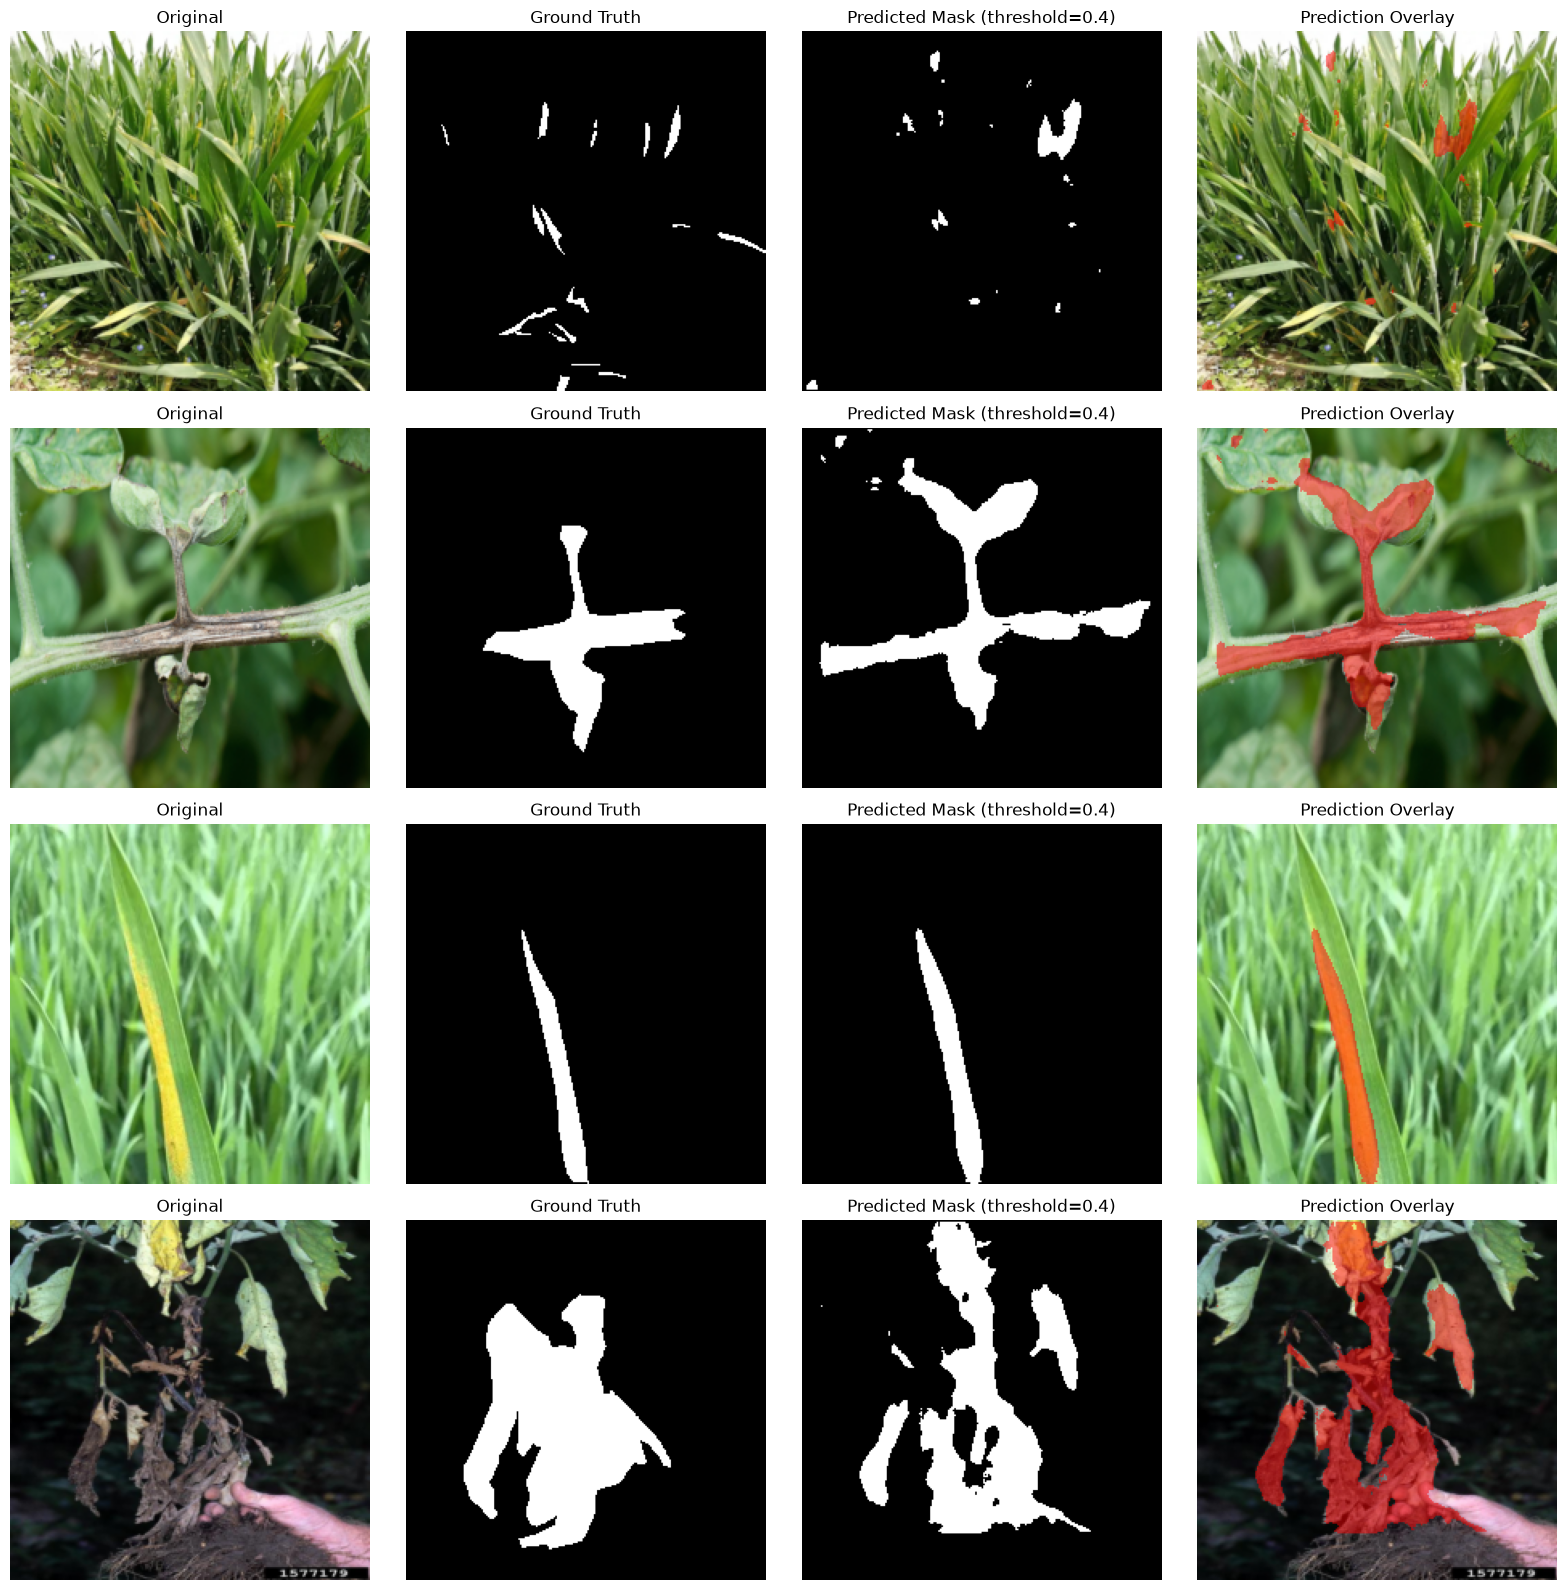

In [31]:
def show_final_segmentation_predictions(
    model,
    dataset,
    threshold=0.4,
    n=4,
    random_state=42
):
    model.eval()

    rng = np.random.default_rng(random_state)
    indices = rng.choice(len(dataset), size=n, replace=False)

    fig, axes = plt.subplots(n, 4, figsize=(16, 4 * n))

    with torch.no_grad():

        for row_idx, idx in enumerate(indices):

            image, mask = dataset[idx]

            input_tensor = image.unsqueeze(0).to(device)

            output = model(input_tensor)

            probability = torch.sigmoid(
                output
            )[0, 0].cpu().numpy()

            predicted_mask = probability >= threshold

            image_np = image.permute(
                1, 2, 0
            ).numpy()

            mask_np = mask.squeeze(0).numpy()

            # Create prediction overlay
            overlay = (
                image_np * 255
            ).astype(np.uint8).copy()

            overlay[predicted_mask] = (
                0.5 * overlay[predicted_mask]
                + 0.5 * np.array([255, 0, 0])
            ).astype(np.uint8)

            axes[row_idx, 0].imshow(image_np)
            axes[row_idx, 0].set_title("Original")

            axes[row_idx, 1].imshow(
                mask_np,
                cmap="gray"
            )
            axes[row_idx, 1].set_title("Ground Truth")

            axes[row_idx, 2].imshow(
                predicted_mask,
                cmap="gray"
            )
            axes[row_idx, 2].set_title(
                f"Predicted Mask (threshold={threshold})"
            )

            axes[row_idx, 3].imshow(overlay)
            axes[row_idx, 3].set_title(
                "Prediction Overlay"
            )

            for col in range(4):
                axes[row_idx, col].axis("off")

    plt.tight_layout()
    plt.show()


show_final_segmentation_predictions(
    model,
    test_dataset,
    threshold=best_threshold,
    n=4
)

   epoch  train_loss  val_loss  time_seconds
0      1    1.164650  1.141022   3286.455153
1      2    1.061487  1.023009   3260.933927
2      3    1.028555  0.991223   3391.399577
3      4    0.996873  0.966310   4043.084848
4      5    0.974798  0.946282   3138.970342


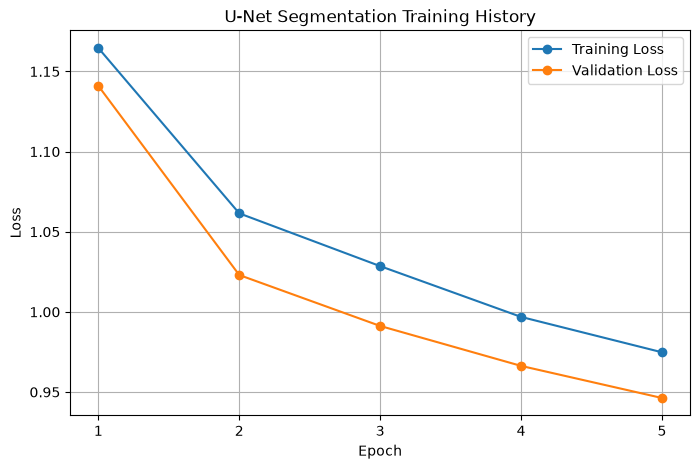

In [32]:
history_df = pd.DataFrame(history)

print(history_df)

plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("U-Net Segmentation Training History")
plt.xticks(history_df["epoch"])
plt.legend()
plt.grid(True)
plt.show()

## Segmentation Baseline Conclusion

A lightweight U-Net model was developed to localize diseased regions using the pixel-level masks provided by the PlantSeg dataset.

The experiment used the cleaned 7,399-image dataset with the established Training, Validation, and Test splits. Images and masks were resized to 224×224, with nearest-neighbor interpolation used for masks to preserve binary labels. Training used batch size 16 and a combined BCE + Dice loss.

### Test Performance

| Metric | Result |
|---|---:|
| Dice | 0.5233 |
| IoU | 0.3971 |
| Pixel Accuracy | 0.8198 |

A probability threshold of 0.4 was selected using the validation set. This improved the test Dice score from 0.5110 at the default 0.5 threshold to 0.5233.

### Observations

The model successfully learned to identify meaningful disease regions. Visual inspection showed that larger diseased regions were generally localized correctly, while small or thin lesions were more frequently missed. Some predictions also extended beyond the ground-truth boundaries.

The decreasing training and validation losses across all five epochs indicate that the model continued to improve during training without an obvious validation-loss divergence.

This U-Net is retained as the baseline segmentation model for the AgriSense localization component.

### Model Checkpoint

Best checkpoint:

`models/checkpoints/unet_segmentation_best.pth`

The segmentation model will be integrated with the disease classifier in a later stage of the AgriSense pipeline.